In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

Se hace el proceso correspondiente a los datos como en el archivo del inciso 1 al 6

In [4]:
filename= 'datos_limpios.csv'
data= pd.read_csv(filename)
df=pd.DataFrame(data)
df.head()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0
2,1.0,1.0,30.23466,-97.73682,2,1.0,1.0,1.0,38.0,4,...,0,0,0,0,1,0,0,0,0,0
3,2.0,2.0,30.26098,-97.73072,3,2.0,2.0,2.0,145.0,15,...,0,0,0,0,1,0,0,0,0,0
4,1.0,1.0,30.23614,-97.73225,2,1.0,1.0,1.0,58.0,30,...,0,0,0,1,0,0,0,0,0,0


Se reemplazan los NaN con medianas

In [6]:
df = df.fillna(df.median(numeric_only=True))

Se crean las categorías y se elimina la variable price, pues es lo que se ha de averiguar con los modelos

In [7]:
categoria = []
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])
df['categoria'] = categoria

In [8]:
dummies = pd.get_dummies(df['categoria'], dtype=int)
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['categoria'])
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,...,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30,Cara,Económica,Intermedia
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,2,90,...,0,1,0,0,0,0,0,0,1,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,3,365,...,0,1,0,0,0,0,0,0,0,1


Separación de variables

In [10]:
# Crear variable objetivo binaria: 1 si es 'Cara', 0 si no lo es
y_binario = df['Cara']

# Eliminar las variables objetivo del conjunto de características para evitar fuga de datos
X = df.drop(columns=['Cara', 'Económica', 'Intermedia'])

# Separación de datos (Fijando random_state=0 para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y_binario, test_size=0.2, random_state=0, stratify=y_binario)

Modelo de Regresión Logística

In [11]:
# Se inicializa el modelo. max_iter se aumenta para asegurar que el algoritmo converja con muchos datos
modelo_logistico = LogisticRegression(random_state=0, max_iter=5000)

# Validación cruzada con 5 divisiones (folds) en el conjunto de entrenamiento
puntuaciones_cv = cross_val_score(modelo_logistico, X_train, y_train, cv=5, scoring='accuracy')

print("Puntuaciones de Validación Cruzada (Precisión):", puntuaciones_cv)
print(f"Precisión promedio en entrenamiento (CV): {np.mean(puntuaciones_cv):.4f}")

# Entrenamos el modelo con todo el conjunto de entrenamiento para los siguientes incisos
modelo_logistico.fit(X_train, y_train)

C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

Puntuaciones de Validación Cruzada (Precisión): [0.85188647 0.8521414  0.84568321 0.84585316 0.8528087 ]
Precisión promedio en entrenamiento (CV): 0.8497


C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

Inciso 7: Ajuste del modelo

In [17]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo_logistico", modelo_logistico)
])


In [18]:
#Se define el espacio de busqueda
param_grid = {
    "modelo_logistico__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "modelo_logistico__penalty": ["l2"],
    "modelo_logistico__solver": ["lbfgs"]
}

In [19]:
from sklearn.model_selection import GridSearchCV
#Se usa GridSearchCV para la regresion logistica porque varios recursos (entre ellos, la documentacion de sckit-learn)
#coinciden en que GridSearch es el más adecuado para este metodo.
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # MÉTRICA adecuada al problema
    n_jobs=-1
)

grid.fit(X_train, y_train) #Se usan los datos de entrenamiento


C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo_logistico__C': [0.001, 0.01, ...], 'modelo_logistico__penalty': ['l2'], 'modelo_logistico__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [20]:
print("Mejores Parametros",grid.best_params_)

Mejores Parametros {'modelo_logistico__C': 100, 'modelo_logistico__penalty': 'l2', 'modelo_logistico__solver': 'lbfgs'}


Inciso 8: Análisis de la eficiencia del modelo del inciso 7 por medio de una matriz de confusión.

C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _chec

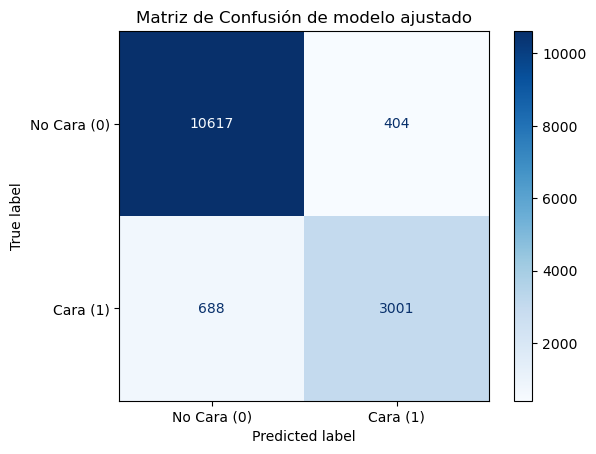

In [22]:
modelo_logistico2 = LogisticRegression(penalty='l2',C=100,random_state=0, solver='lbfgs',max_iter=5000)
modelo_logistico2.fit(X_test, y_test)
y_pred_test = modelo_logistico2.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cara (0)', 'Cara (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión de modelo ajustado")
plt.show()


Se observa que en relación al primer modelo descrito en el Inciso 5, este modelo resulta mejor para predicción de las propiedades caras. Esto porque aquellas que han sido predictas correctamente como propiedades 'Caras' son 3001, mientras que en el primer modelo eran de 1771. Asimismo, la cantidad de valores errados de predicción 'No Cara' cuando era 'Cara' es de 688 en este modelo, mientras que en el primero era de 1918. Aquellas predichas como caras que no lo eran son de 404, mientras que en el anterior eran de 225 predicciones eradas, de manera que este valor ha aumentado.

No obstante,  aquellas predicciones relacionadas con las propiedades tipo 'No Cara' han sido menos precisas que en el modelo anterior. Esto porque en este modelo aquellas que han sido predichas correctamente como 'No Caras' ha sido de 10617 mientras que en el modelo anterior ha sido de 10796, lo que son casi 100 propiedades de diferencia entre un modelo y otro respecto a esta clasificación.

Inciso 9: Cambio de umbral del modelo